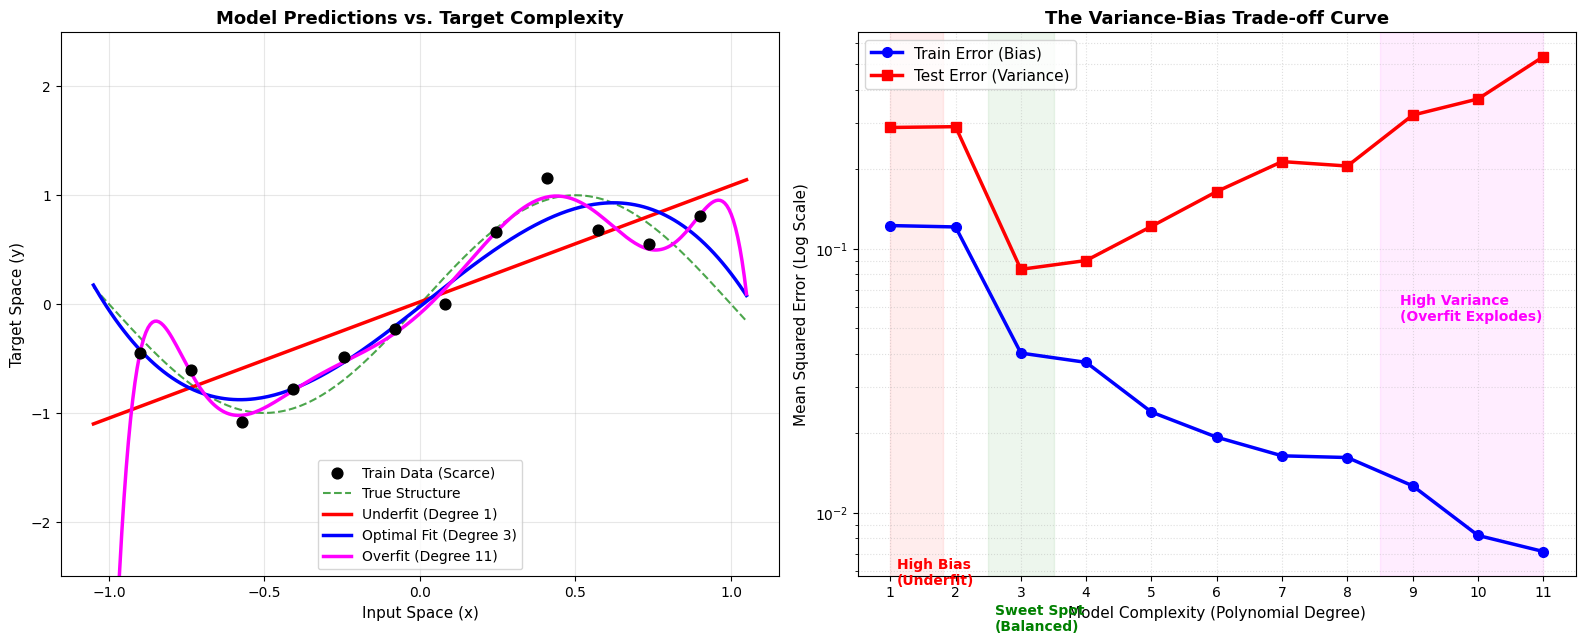

In [3]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 1. REPRODUCIBILITY & DATA GENERATION
# ============================================================
torch.manual_seed(15)  # Seed selected for highly erratic edge oscillations
np.random.seed(15)

def true_function(x):
    return torch.sin(np.pi * x)

# CRITICAL CHANGE: Reduced to 12 points to trigger extreme overfitting/variance
N_train = 12
x_train = torch.linspace(-0.9, 0.9, N_train).unsqueeze(1)
y_train = true_function(x_train) + torch.randn_like(x_train) * 0.20

N_test = 100
x_test = torch.linspace(-1, 1, N_test).unsqueeze(1)
y_test = true_function(x_test) + torch.randn_like(x_test) * 0.20

# Extended smooth evaluation grid to capture out-of-bounds edge variance
x_range = torch.linspace(-1.05, 1.05, 300).unsqueeze(1)

# ============================================================
# 2. FEATURE EXTRACTION HELPER
# ============================================================
def generate_poly_features(x, degree):
    features = [x ** i for i in range(1, degree + 1)]
    return torch.cat(features, dim=1)

# ============================================================
# 3. TRAINING ENGINE
# ============================================================
def train_polynomial_model(degree, epochs=6000, lr=0.01):
    X_train_poly = generate_poly_features(x_train, degree)
    X_test_poly = generate_poly_features(x_test, degree)
    X_range_poly = generate_poly_features(x_range, degree)
    
    model = nn.Linear(degree, 1)
    criterion = nn.MSELoss()
    
    # Using Adam to stabilize optimization across highly diverse feature scales
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    
    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        loss = criterion(model(X_train_poly), y_train)
        loss.backward()
        optimizer.step()
        
    model.eval()
    with torch.no_grad():
        train_mse = criterion(model(X_train_poly), y_train).item()
        test_mse = criterion(model(X_test_poly), y_test).item()
        range_preds = model(X_range_poly)
        
    return train_mse, test_mse, range_preds

# ============================================================
# 4. SWEEPING DEGREES
# ============================================================
degrees = list(range(1, 12))
train_errors = []
test_errors = []
predictions_dict = {}

for d in degrees:
    tr_err, te_err, preds = train_polynomial_model(degree=d)
    train_errors.append(tr_err)
    test_errors.append(te_err)
    predictions_dict[d] = preds

# ============================================================
# 5. VISUALIZATION PLOTS
# ============================================================
plt.figure(figsize=(16, 6.5))

# --- Plot 1: Visual Predictions ---
plt.subplot(1, 2, 1)
plt.scatter(x_train.numpy(), y_train.numpy(), color='black', s=60, label='Train Data (Scarce)', zorder=5)
plt.plot(x_range.numpy(), true_function(x_range).numpy(), color='green', linestyle='--', alpha=0.7, label='True Structure')

target_degrees = {
    1: ('red', 'Underfit (Degree 1)'), 
    3: ('blue', 'Optimal Fit (Degree 3)'), 
    11: ('magenta', 'Overfit (Degree 11)') # Maximum capacity model
}

for d, (color, label) in target_degrees.items():
    plt.plot(x_range.numpy(), predictions_dict[d].numpy(), color=color, linewidth=2.5, label=label)

plt.ylim(-2.5, 2.5) # Tight boundary isolates the wild edge oscillations
plt.title("Model Predictions vs. Target Complexity", fontsize=13, fontweight='bold')
plt.xlabel("Input Space (x)", fontsize=11)
plt.ylabel("Target Space (y)", fontsize=11)
plt.legend(loc='lower center')
plt.grid(True, alpha=0.3)

# --- Plot 2: Enhanced Variance-Bias U-Curve ---
plt.subplot(1, 2, 2)
plt.plot(degrees, train_errors, marker='o', markersize=7, color='blue', linewidth=2.5, label='Train Error (Bias)')
plt.plot(degrees, test_errors, marker='s', markersize=7, color='red', linewidth=2.5, label='Test Error (Variance)')

plt.yscale('log') # Essential for rendering the massive numeric split beautifully
plt.xlabel("Model Complexity (Polynomial Degree)", fontsize=11)
plt.ylabel("Mean Squared Error (Log Scale)", fontsize=11)
plt.title("The Variance-Bias Trade-off Curve", fontsize=13, fontweight='bold')
plt.xticks(degrees)
plt.grid(True, which="both", alpha=0.4, linestyle=':')

# Explicit structural annotations of the zones
plt.axvspan(1, 1.8, color='red', alpha=0.07)
plt.text(1.1, max(test_errors)*0.01, "High Bias\n(Underfit)", color='red', fontsize=10, weight='bold')

plt.axvspan(2.5, 3.5, color='green', alpha=0.07)
plt.text(2.6, min(train_errors)*0.5, "Sweet Spot\n(Balanced)", color='green', fontsize=10, weight='bold')

plt.axvspan(8.5, 11, color='magenta', alpha=0.07)
plt.text(8.8, max(test_errors)*0.1, "High Variance\n(Overfit Explodes)", color='magenta', fontsize=10, weight='bold')

plt.legend(loc='upper left', fontsize=11)
plt.tight_layout()
plt.show()

Training Underfit Model (1 Neuron)...
Training Overfit Model (1024 Neurons, No Regularization)...
Training Regularized Model (1024 Neurons, Weight Decay)...


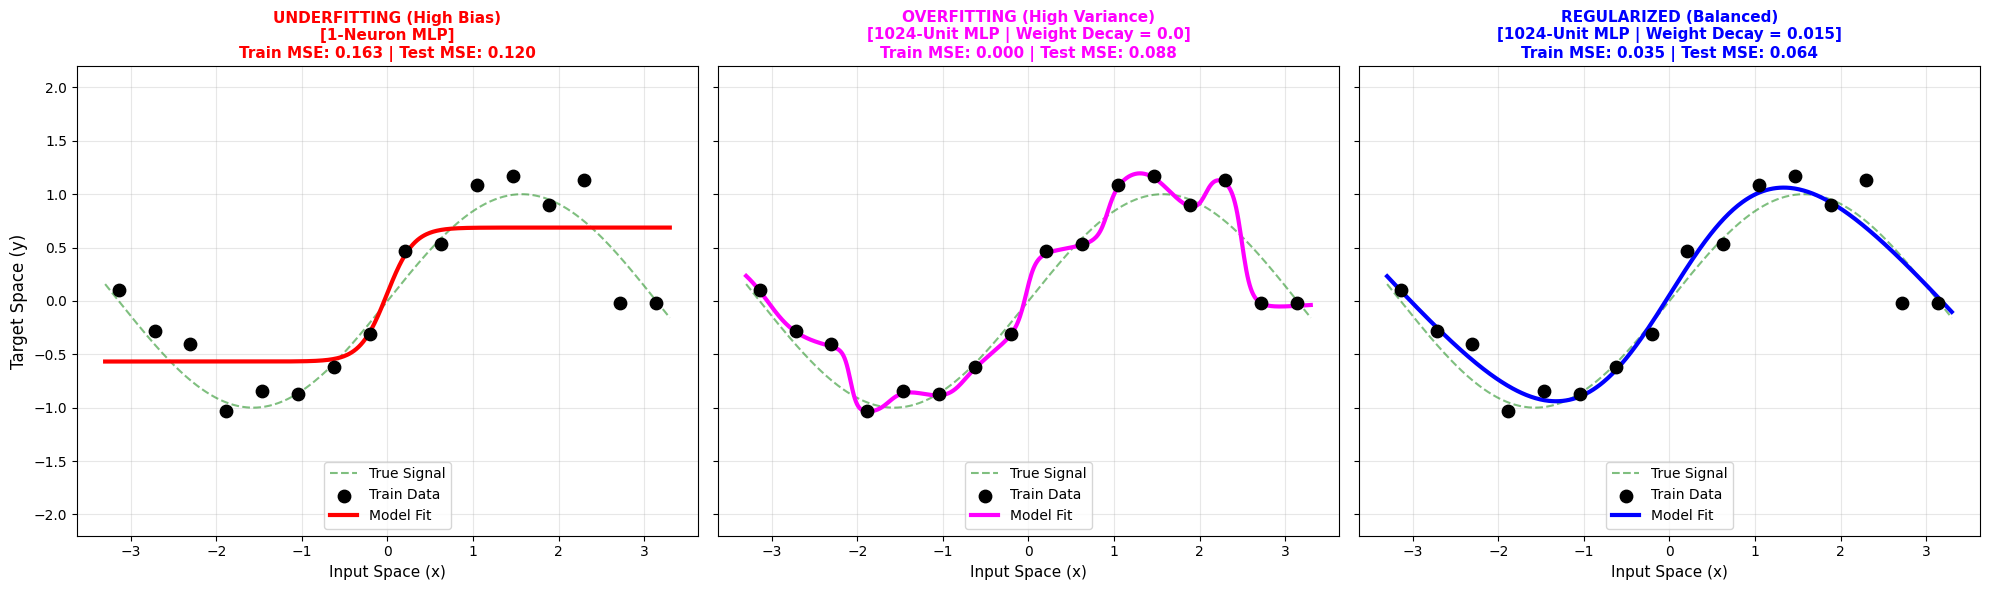

In [21]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 1. REPRODUCIBILITY & DATA GENERATION (Fixed Frequency)
# ============================================================
torch.manual_seed(20) 
np.random.seed(20)

def true_function(x):
    # Pure sine wave mapping across domain bounds (-pi to pi)
    return torch.sin(x)

N_train = 16
x_train = torch.linspace(-3.14, 3.14, N_train).unsqueeze(1)
y_train = true_function(x_train) + torch.randn_like(x_train) * 0.22

N_test = 200
x_test = torch.linspace(-3.14, 3.14, N_test).unsqueeze(1)
y_test = true_function(x_test) + torch.randn_like(x_test) * 0.22

x_range = torch.linspace(-3.3, 3.3, 500).unsqueeze(1)

# ============================================================
# 2. ARCHITECTURE CODES (Structural vs. Regularized Control)
# ============================================================
class DemonstrationMLP(nn.Module):
    def __init__(self, mode):
        super().__init__()
        
        if mode == "underfit":
            # Structural Bottleneck: 1 Neuron cannot replicate an S-curve/Sine wave
            self.network = nn.Sequential(
                nn.Linear(1, 1),
                nn.Tanh(),
                nn.Linear(1, 1)
            )
        elif mode in ["overfit", "regularized"]:
            # Massive structural capacity 
            self.network = nn.Sequential(
                nn.Linear(1, 1024),
                nn.Tanh(),
                nn.Linear(1024, 1024),
                nn.Tanh(),
                nn.Linear(1024, 1024),
                nn.Tanh(),
                nn.Linear(1024, 1)  
            )

    def forward(self, x):
        return self.network(x)

# ============================================================
# 3. TRAINING ENGINE
# ============================================================
def train_model(mode, epochs, lr, weight_decay=0.0):
    model = DemonstrationMLP(mode)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    
    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        loss = criterion(model(x_train), y_train)
        loss.backward()
        optimizer.step()
        
    model.eval()
    with torch.no_grad():
        train_mse = criterion(model(x_train), y_train).item()
        test_mse = criterion(model(x_test), y_test).item()
        preds = model(x_range)
        
    return train_mse, test_mse, preds

# ============================================================
# 4. RUNNING EXPERIMENTS
# ============================================================
print("Training Underfit Model (1 Neuron)...")
underfit_train, underfit_test, underfit_preds = train_model("underfit", epochs=3000, lr=0.01)

print("Training Overfit Model (1024 Neurons, No Regularization)...")
overfit_train, overfit_test, overfit_preds = train_model("overfit", epochs=8000, lr=0.0003, weight_decay=0.0)

print("Training Regularized Model (1024 Neurons, Weight Decay)...")
reg_train, reg_test, reg_preds = train_model("regularized", epochs=8000, lr=0.0003, weight_decay=0.015)

# ============================================================
# 5. HIGH-VISIBILITY VISUALIZATION
# ============================================================
fig, axs = plt.subplots(1, 3, figsize=(20, 6), sharey=True)

for ax in axs:
    ax.plot(x_range.numpy(), true_function(x_range).numpy(), color='green', linestyle='--', alpha=0.5, label='True Signal')
    ax.scatter(x_train.numpy(), y_train.numpy(), color='black', s=80, label='Train Data', zorder=5)
    ax.grid(True, alpha=0.3)
    ax.set_xlabel("Input Space (x)", fontsize=11)

axs[0].set_ylabel("Target Space (y)", fontsize=12)

# --- PANEL 1: UNDERFITTING (Capacity Starved) ---
axs[0].plot(x_range.numpy(), underfit_preds.numpy(), color='red', linewidth=3, label='Model Fit')
axs[0].set_title(f"UNDERFITTING (High Bias)\n[1-Neuron MLP]\nTrain MSE: {underfit_train:.3f} | Test MSE: {underfit_test:.3f}", color='red', fontsize=11, fontweight='bold')
axs[0].legend(loc='lower center')

# --- PANEL 2: OVERFITTING (Capacity Exploded) ---
axs[1].plot(x_range.numpy(), overfit_preds.numpy(), color='magenta', linewidth=3, label='Model Fit')
axs[1].set_title(f"OVERFITTING (High Variance)\n[1024-Unit MLP | Weight Decay = 0.0]\nTrain MSE: {overfit_train:.3f} | Test MSE: {overfit_test:.3f}", color='magenta', fontsize=11, fontweight='bold')
axs[1].legend(loc='lower center')

# --- PANEL 3: REGULARIZED OPTIMAL (Capacity Controlled) ---
axs[2].plot(x_range.numpy(), reg_preds.numpy(), color='blue', linewidth=3, label='Model Fit')
axs[2].set_title(f"REGULARIZED (Balanced)\n[1024-Unit MLP | Weight Decay = 0.015]\nTrain MSE: {reg_train:.3f} | Test MSE: {reg_test:.3f}", color='blue', fontsize=11, fontweight='bold')
axs[2].legend(loc='lower center')

plt.ylim(-2.2, 2.2)
plt.tight_layout()
plt.show()